In this notebook, a logistic regression model will be trained on each data set processed in the 01_PreProcessing notebook. 

In [1]:
import sys
from pathlib import Path
import psycopg2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

src_path = Path.cwd().parent / "src"
sys.path.append(str(src_path))

In [2]:
db_user = os.environ.get("POSTGRES_USER")
db_pass = os.environ.get("POSTGRES_PASSWORD")
db_host = os.environ.get("POSTGRES_HOST")
db_name = os.environ.get("POSTGRES_DB")

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:5432/{db_name}")

In [10]:
wirbelj_clr = pd.read_sql("SELECT * FROM wirbelj_relab_filtered_clr", con=engine)

classes_list = wirbelj_clr.pop('Healthy')


In [11]:
# Another preprocessing step to perform is normalisation; some features are larger than others.
# This can skew models ability to generalise.

scaler = StandardScaler()
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=789)

clr_l2_results = pd.DataFrame.from_dict({"FOLD":[],
"TN":[],
"FP":[],
"FN":[],
"TP":[]}
)

clr_l1_results = pd.DataFrame.from_dict({"FOLD":[],
"TN":[],
"FP":[],
"FN":[],
"TP":[]}
)

clr_elastic_results = pd.DataFrame.from_dict({"FOLD":[],
"TN":[],
"FP":[],
"FN":[],
"TP":[]}
)


for i, (train_index, test_index) in enumerate(skf.split(wirbelj_clr, classes_list)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    X_hold_out = wirbelj_clr.iloc[test_index]
    y_hold_out = classes_list[test_index]
    X_train = wirbelj_clr.iloc[train_index]
    y_train = classes_list[train_index]

    X_hold_out_scaled = scaler.fit_transform(X_hold_out)
    X_train_scaled = scaler.fit_transform(X_train)


    clf_l2 = LogisticRegression(random_state=789, penalty='l2', solver='saga').fit(X_train_scaled, y_train)
    clf_l1 = LogisticRegression(random_state=789, penalty='l1', solver='saga').fit(X_train_scaled, y_train)
    clf_elastic = LogisticRegression(random_state=789, penalty='elasticnet', l1_ratio=0.5, solver='saga').fit(X_train_scaled, y_train)
    
    # Evaluate models against hold-out set
    y_predict_l2 = clf_l2.predict(X_hold_out_scaled)
    y_predict_l1 = clf_l1.predict(X_hold_out_scaled)
    y_predict_elastic = clf_elastic.predict(X_hold_out_scaled)

    con_matrix_l2 = confusion_matrix(y_hold_out, y_predict_l2).ravel().tolist()
    con_matrix_l1 = confusion_matrix(y_hold_out, y_predict_l1).ravel().tolist()
    con_matrix_elastic = confusion_matrix(y_hold_out, y_predict_elastic).ravel().tolist()

    con_matrix_l2.insert(0, i)
    con_matrix_l1.insert(0, i)
    con_matrix_elastic.insert(0, i)

    clr_l2_results.loc[len(clr_l2_results)] = con_matrix_l2
    clr_l1_results.loc[len(clr_l1_results)] = con_matrix_l1
    clr_elastic_results.loc[len(clr_elastic_results)] = con_matrix_elastic
    



Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  27  28  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  65  66  67  68  69  71  72  73  76  77  78
  79  80  81  82  84  85  86  88  90  91  92  94  95  96  97  98  99 100
 101 102 103 104 105 106 107 108 109 110 111 112 114 115 116 117]
  Test:  index=[ 26  29  30  64  70  74  75  83  87  89  93 113]
Fold 1:
  Train: index=[  1   2   3   4   5   6   7   8  10  11  12  13  14  16  17  18  19  20
  21  22  23  24  25  26  28  29  30  31  32  33  34  35  37  38  39  40
  41  42  43  44  45  46  47  48  49  50  51  52  53  55  56  57  58  59
  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77
  78  79  80  81  82  83  84  86  87  88  89  90  91  93  94  96  97  99
 100 101 102 103 105 106 107 108 109 110 111 113 114 115 116 117]
  Test:  index=[  0   9  15

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

Fold 2:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  14  15  16  18  20
  21  22  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  49  50  51  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  70  71  72  73  74  75  76  77
  78  79  80  81  82  83  85  86  87  89  90  91  92  93  94  95  97  98
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 115 117]
  Test:  index=[ 13  17  19  23  52  69  84  88  96  99 114 116]
Fold 3:
  Train: index=[  0   1   2   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  43  44  45  47  48  49  50  51  52  53  54  57  58
  59  60  61  63  64  65  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  83  84  85  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 103 104 105 106 109 110 111 112 113 114 115 116 117]
  Test:  index=[  3  42  46

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fold 4:
  Train: index=[  0   1   2   3   4   6   7   8   9  10  12  13  14  15  16  17  19  20
  21  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  64  66  67  68  69  70  71  72  73  74  75  76  77  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 104 105 106 107 108 110 112 113 114 116 117]
  Test:  index=[  5  11  18  22  48  63  65  78 103 109 111 115]
Fold 5:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  13  14  15  16  17  18
  19  22  23  24  25  26  27  28  29  30  32  33  34  35  36  38  39  40
  42  43  45  46  47  48  49  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  92  93  94  95  96  97  98
  99 101 102 103 104 105 107 108 109 111 112 113 114 115 116 117]
  Test:  index=[ 12  20  21

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

Fold 6:
  Train: index=[  0   1   2   3   5   6   8   9  10  11  12  13  14  15  17  18  19  20
  21  22  23  25  26  27  28  29  30  31  35  36  37  38  39  40  41  42
  43  44  45  46  48  49  50  51  52  53  54  55  56  58  60  62  63  64
  65  66  67  68  69  70  71  72  73  74  75  76  77  78  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117]
  Test:  index=[ 4  7 16 24 32 33 34 47 57 59 61 79]
Fold 7:
  Train: index=[  0   1   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  36  37
  38  39  41  42  43  44  45  46  47  48  49  50  52  53  54  55  56  57
  59  60  61  62  63  64  65  66  69  70  71  72  74  75  76  78  79  81
  82  83  84  85  86  87  88  89  90  91  92  93  95  96  97  98  99 100
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117]
  Test:  index=[  2  35  40  51  58  67

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fold 8:
  Train: index=[  0   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18  19
  20  21  22  23  24  25  26  27  29  30  31  32  33  34  35  36  37  39
  40  41  42  44  45  46  47  48  50  51  52  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  72  73  74  75  76  77  78  79
  80  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 104 106 107 108 109 110 111 112 113 114 115 116]
  Test:  index=[  1  14  28  38  43  49  53  71  81 105 117]
Fold 9:
  Train: index=[  0   1   2   3   4   5   7   9  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  26  27  28  29  30  31  32  33  34  35  36  37  38  40
  41  42  43  44  46  47  48  49  50  51  52  53  54  55  56  57  58  59
  61  62  63  64  65  66  67  68  69  70  71  73  74  75  77  78  79  80
  81  82  83  84  85  86  87  88  89  91  92  93  94  95  96  98  99 100
 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117]
  Test:  index=[ 6  8 1

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

In [16]:
# Assess each models performance. 

# Accuracy
clr_l2_results["ACCURACY"] = (clr_l2_results["TN"]+clr_l2_results["TP"])/clr_l2_results[["TP", "TN", "FN", "FP"]].sum(axis=1)
clr_l1_results["ACCURACY"] = (clr_l1_results["TN"]+clr_l1_results["TP"])/clr_l1_results[["TP", "TN", "FN", "FP"]].sum(axis=1)
clr_elastic_results["ACCURACY"] = (clr_elastic_results["TN"]+clr_elastic_results["TP"])/clr_elastic_results[["TP", "TN", "FN", "FP"]].sum(axis=1)

# Precision
clr_l2_results["PRECISION"] = clr_l2_results["TP"]/clr_l2_results[["TP", "FP"]].sum(axis=1)
clr_l1_results["PRECISION"] = clr_l1_results["TP"]/clr_l1_results[["TP", "FP"]].sum(axis=1)
clr_elastic_results["PRECISION"] = clr_elastic_results["TP"]/clr_elastic_results[["TP", "FP"]].sum(axis=1)

# Recall
clr_l2_results["RECALL"] = clr_l2_results["TP"]/clr_l2_results[["TP", "FN"]].sum(axis=1)
clr_l1_results["RECALL"] = clr_l1_results["TP"]/clr_l1_results[["TP", "FN"]].sum(axis=1)
clr_elastic_results["RECALL"] = clr_elastic_results["TP"]/clr_elastic_results[["TP", "FN"]].sum(axis=1)


In [43]:
# Plot average scores for each model

accuracy_compiled = pd.DataFrame(index=np.arange(10), columns=('FOLD', 'l2_acc', 'l1_acc', 'elastic_acc'))

precision_compiled = pd.DataFrame(index=np.arange(10), columns=('FOLD', 'l2_acc', 'l1_acc', 'elastic_acc'))

recall_compiled = pd.DataFrame(index=np.arange(10), columns=('FOLD', 'l2_acc', 'l1_acc', 'elastic_acc'))

 
accuracy_compiled["FOLD"] = clr_l2_results["FOLD"]
accuracy_compiled["l2_acc"] = clr_l2_results["ACCURACY"]
accuracy_compiled["l1_acc"] = clr_l1_results["ACCURACY"]
accuracy_compiled["elastic_acc"] = clr_elastic_results["ACCURACY"]

precision_compiled["FOLD"] = clr_l2_results["FOLD"]
precision_compiled["l2_pre"] = clr_l2_results["PRECISION"]
precision_compiled["l1_pre"] = clr_l1_results["PRECISION"]
precision_compiled["elastic_pre"] = clr_elastic_results["PRECISION"]

recall_compiled["FOLD"] = clr_l2_results["FOLD"]
recall_compiled["l2_recall"] = clr_l2_results["RECALL"]
recall_compiled["l1_recall"] = clr_l1_results["RECALL"]
recall_compiled["elastic_recall"] = clr_elastic_results["RECALL"]


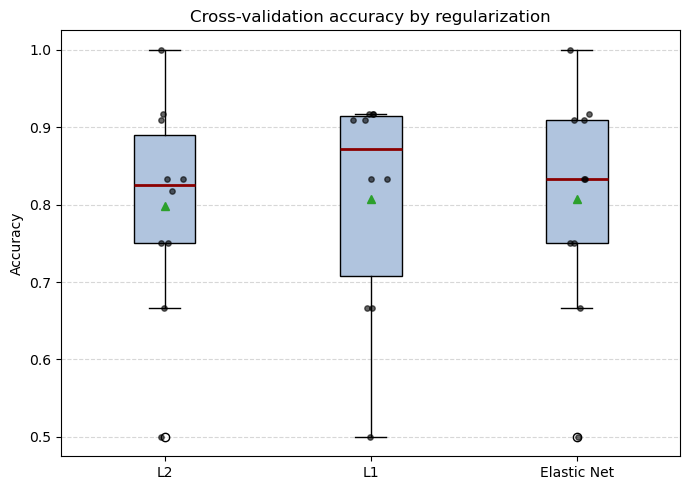

In [58]:
cols = ["l2_acc", "l1_acc", "elastic_acc"]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [accuracy_compiled[c] for c in cols],
    labels=["L2", "L1", "Elastic Net"],  
    whis=1.5,            
    showmeans=True,      
    patch_artist=True,   
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="darkred", linewidth=2),
)

for i, c in enumerate(cols, start=1):
    x = np.random.normal(i, 0.04, size=len(accuracy_compiled))
    ax.scatter(x, accuracy_compiled[c], alpha=0.6, color="black", s=15, zorder=3)


ax.set_ylabel("Accuracy")
ax.set_title("Cross-validation accuracy by regularization")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

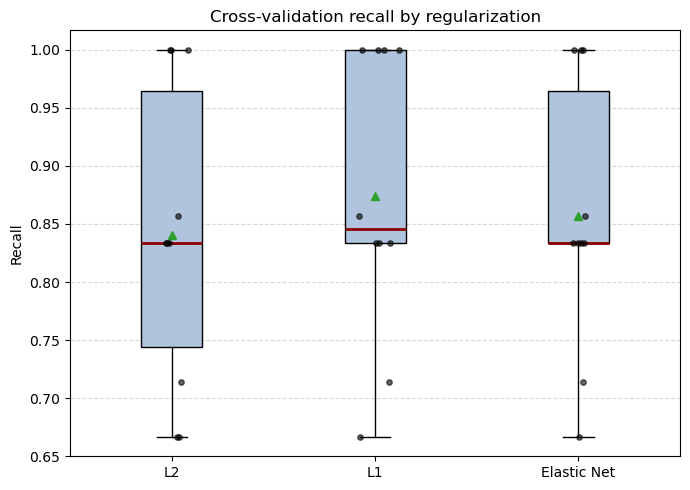

In [57]:
cols = ["l2_recall", "l1_recall", "elastic_recall"]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [recall_compiled[c] for c in cols],
    labels=["L2", "L1", "Elastic Net"],  
    whis=1.5,            
    showmeans=True,      
    patch_artist=True,   
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="darkred", linewidth=2),
)

for i, c in enumerate(cols, start=1):
    x = np.random.normal(i, 0.04, size=len(recall_compiled))
    ax.scatter(x, recall_compiled[c], alpha=0.6, color="black", s=15, zorder=3)

ax.set_ylabel("Recall")
ax.set_title("Cross-validation recall by regularization")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

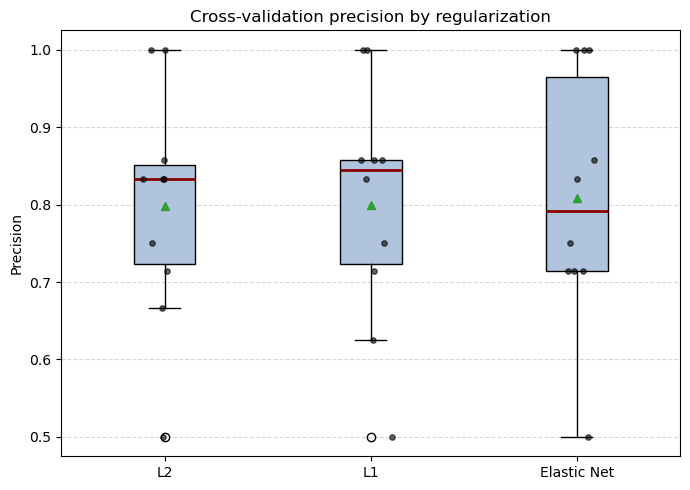

In [51]:
cols = ["l2_pre", "l1_pre", "elastic_pre"]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [precision_compiled[c] for c in cols],
    labels=["L2", "L1", "Elastic Net"],  # use `labels=` on Matplotlib < 3.9
    whis=1.5,            # whiskers extend to 1.5 * IQR (the default)
    showmeans=True,      # optional: marks the mean with a green triangle
    patch_artist=True,   # allows filling the boxes with color
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="darkred", linewidth=2),
)

for i, c in enumerate(cols, start=1):
    x = np.random.normal(i, 0.04, size=len(precision_compiled))
    ax.scatter(x, precision_compiled[c], alpha=0.6, color="black", s=15, zorder=3)


ax.set_ylabel("Precision")
ax.set_title("Cross-validation precision by regularization")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()